In [1]:
import numpy as np
import numpy as np
import torch
import sys, os
sys.path.append(os.path.abspath(".."))  # project root
print(os.path.abspath(".."))
from datasets.data import SpatialDataset
from datasets.transformerRegressorDataClass import TransformerPointDataset, collate_point_batches
from torch.utils.data import DataLoader
#from datasets.dt2_data import load_dt2_data
from models.transformerRegressor import TransformerCLSRegressor
import numpy as np
import matplotlib.pyplot as plt
from argument_transformer import parse_opt

/home/user_116/Project-B-Technion/Transformer_Map_Interp


In [3]:
@torch.no_grad()
def evaluate_split(model, dataset, trainset, device):
    ds = TransformerPointDataset(dataset, trainset, device=device)
    loader = DataLoader(ds, batch_size=32, shuffle=False, collate_fn=collate_point_batches)

    preds, trues, coords = [], [], []
    y_mean, y_std = trainset.y_mean.to(device), trainset.y_std.to(device)

    model.eval()
    for mem, mask, y, cls_coord in loader:
        mem, mask, y = mem.to(device), mask.to(device), y.to(device)
        y_hat = model(mem, mask)

        # denormalize
        y_hat_real = y_hat * y_std + y_mean
        y_real = y * y_std + y_mean

        preds.append(y_hat_real.cpu())
        trues.append(y_real.cpu())
        coords.append(cls_coord.cpu())

    preds = torch.cat(preds)
    trues = torch.cat(trues)
    coords = torch.cat(coords)

    abs_err = torch.abs(preds - trues)
    #rel_err = abs_err / (torch.abs(trues) + 1e-6)
    return coords, abs_err#, rel_err


def plot_error_map(coords, errors, title="Error map", cmap="inferno"):
    plt.figure(figsize=(10,8))
    sc = plt.scatter(coords[:,1], coords[:,0], c=errors, s=6, cmap=cmap)
    plt.colorbar(sc, label="Absolute Error (m)")
    plt.xlabel("Longitude"); plt.ylabel("Latitude")
    plt.title(title)
    plt.show()

In [2]:
# Show the current working directory
from pathlib import Path
print(os.getcwd())
os.chdir("..")
sys.path.append(os.path.abspath(".."))  # project root
print(os.path.abspath(".."))
p_cache = Path("cache")
print("cache exists?", p_cache.exists(), "->", p_cache.resolve())
trainset = torch.load(r"./Transformer_Map_Interp/cache/trainset_n32_e035_1arc_v3_cropped_train_n32_e035_1arc_v3_cropped_val_n32_e035_1arc_v3_cropped_test_keep_n0.05_seed5.pt",map_location="cpu",weights_only=False)
validset = torch.load(r"./Transformer_Map_Interp/cache/validset_n32_e035_1arc_v3_cropped_train_n32_e035_1arc_v3_cropped_val_n32_e035_1arc_v3_cropped_test_keep_n0.05_seed5.pt",map_location="cpu",weights_only=False)
testset = torch.load(r"./Transformer_Map_Interp/cache/testset_n32_e035_1arc_v3_cropped_train_n32_e035_1arc_v3_cropped_val_n32_e035_1arc_v3_cropped_test_keep_n0.05_seed5.pt",map_location="cpu",weights_only=False)

/home/user_116/Project-B-Technion/Transformer_Map_Interp/display
/home/user_116/Project-B-Technion
cache exists? True -> /home/user_116/Project-B-Technion/Transformer_Map_Interp/cache


FileNotFoundError: [Errno 2] No such file or directory: './Transformer_Map_Interp/cache/trainset_n32_e035_1arc_v3_cropped_train_n32_e035_1arc_v3_cropped_val_n32_e035_1arc_v3_cropped_test_keep_n0.05_seed5.pt'

In [3]:
# Show the current working directory
from pathlib import Path
print(os.getcwd())
#os.chdir("..")
sys.path.append(os.path.abspath(".."))  # project root
print(os.path.abspath(".."))
p_cache = Path("cache")
print("cache exists?", p_cache.exists(), "->", p_cache.resolve())
trainset = torch.load(r"./cache/trainset_n32_e035_1arc_v3_cropped_train_n32_e035_1arc_v3_cropped_val_n32_e035_1arc_v3_cropped_test_keep_n0.005_seed5.pt",map_location="cpu",weights_only=False)
validset = torch.load(r"./cache/validset_n32_e035_1arc_v3_cropped_train_n32_e035_1arc_v3_cropped_val_n32_e035_1arc_v3_cropped_test_keep_n0.005_seed5.pt",map_location="cpu",weights_only=False)
testset = torch.load(r"./cache/testset_n32_e035_1arc_v3_cropped_train_n32_e035_1arc_v3_cropped_val_n32_e035_1arc_v3_cropped_test_keep_n0.005_seed5.pt",map_location="cpu",weights_only=False)

/home/user_116/Project-B-Technion/Transformer_Map_Interp
/home/user_116/Project-B-Technion
cache exists? True -> /home/user_116/Project-B-Technion/Transformer_Map_Interp/cache


In [5]:
avg_size = sum(len(inner) for inner in validset.obs_coords_norm) / len(validset.obs_coords_norm)
print(f"Number of neighbors at Val set: {avg_size}")

avg_size = sum(len(inner) for inner in testset.obs_coords_norm) / len(testset.obs_coords_norm)
print(f"Number of neighbors at Test set: {avg_size}")

avg_size = sum(len(inner) for inner in trainset.obs_coords_norm) / len(trainset.obs_coords_norm)
print(f"Number of neighbors at Train set:{avg_size}")

print(trainset.y_std.detach().cpu().numpy())
print(trainset.y_mean.detach().cpu().numpy())
print(len(trainset.obs_y))
print(len(validset.obs_y))
print(len(testset.obs_y))

Number of neighbors at Val set: 10.715502345099976
Number of neighbors at Test set: 10.790175265366576
Number of neighbors at Train set:10.915136435606918
301.6628
273.4355
48631
8102
8102


In [15]:
import argparse
import torch
argv_bak = sys.argv
try:
    sys.argv = [argv_bak[0]]  # keep program name only; drop Jupyter’s flags
    args = parse_opt()
finally:
    sys.argv = argv_bak
args.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
args.dropout = 0.0
args.model = "transformer"
in_dim = 3  # [Δlat, Δlon, y_known_norm, is_observed] # Orit 12.10 from 4 --> 3
print("Using device:", args.device)
model = TransformerCLSRegressor(
    in_dim=in_dim,
    d_model=args.d_model,
    nhead=args.n_heads,       # keep your arg names as-is
    num_layers=args.n_layers, # keep your arg names as-is
    dim_feedforward=args.ffn_dim,
    dropout=args.dropout,
    #cls_init=args.cls_init,
    use_posenc=args.use_posenc,
).to(args.device)
print("Model initialized:")
print(model)
#os.chdir("..")
sys.path.append(os.path.abspath("../"))  # project root
print(os.path.abspath("../"))
print("Current working directory:", os.getcwd())
print("File exists?", os.path.exists("saved_models/Exp_5/best_model_19.pt"))
ckpt_path = f"saved_models/Exp_5/best_model_19.pt"
last_path = f"saved_models/Exp_5/last_epoch_model.pt"
print(f"Loading checkpoint from {ckpt_path}")
model.load_state_dict(torch.load(ckpt_path, map_location=args.device))

device: cuda
Using device: cuda
Model initialized:
TransformerCLSRegressor(
  (in_proj): Linear(in_features=3, out_features=256, bias=True)
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-7): 8 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=256, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=256, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm3): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=Fal

<All keys matched successfully>

Display the errors as error map

In [16]:
@torch.no_grad()
def predict(dataset, trainset):
    ds = TransformerPointDataset(dataset, trainset, device=args.device)
    loader = DataLoader(ds, batch_size=64, shuffle=False, collate_fn=collate_point_batches)
    preds, trues, coords = [], [], []

    for mem, mask, y, cls_coords in loader:
        mem, mask = mem.to(args.device), mask.to(args.device)
        y_hat = model(mem, mask)
        y_hat_real = y_hat * trainset.y_std + trainset.y_mean
        y_real = y * trainset.y_std + trainset.y_mean
        preds.append(y_hat_real.cpu())
        trues.append(y_real.cpu())
        coords.append(cls_coords.cpu())

    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()
    coords = torch.cat(coords).numpy()
    errors = preds - trues
    return coords, trues, preds, errors


In [17]:
val_coords, val_true, val_pred, val_err = predict(validset, trainset)
test_coords, test_true, test_pred, test_err = predict(testset, trainset)

In [80]:
def plot_error_map(coords, true, err, title_prefix,
                   cmap_elev="terrain", cmap_err="coolwarm",
                   elev_norm=None, err_norm=None, save_name=None):
    lons, lats = coords[:,1], coords[:,0]
    fig, axs = plt.subplots(2, 1, figsize=(9, 12), constrained_layout=True)

    # Top: original elevation (shared color scale)
    sc1 = axs[0].scatter(lons, lats, c=true, cmap=cmap_elev, s=6, norm=elev_norm)
    axs[0].set_title(f"{title_prefix} – Original Elevation")
    axs[0].set_xlabel("Longitude"); axs[0].set_ylabel("Latitude")
    plt.colorbar(sc1, ax=axs[0], label="Elevation (m)")

    # Bottom: error (shared, centered at 0)
    sc2 = axs[1].scatter(lons, lats, c=err, cmap=cmap_err, s=6, norm=err_norm)
    axs[1].set_title(f"{title_prefix} – Prediction Error (Pred - True)")
    axs[1].set_xlabel("Longitude"); axs[1].set_ylabel("Latitude")
    plt.colorbar(sc2, ax=axs[1], label="Error (m)")

    if save_name:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()


In [81]:
from matplotlib.colors import Normalize, TwoSlopeNorm

# 1) Elevation uses the SAME vmin/vmax across val+test
elev_min = float(min(val_true.min(), test_true.min()))
elev_max = float(max(val_true.max(), test_true.max()))
elev_norm = Normalize(vmin=elev_min, vmax=elev_max)

# 2) Error uses a symmetric scale around 0, shared across val+test
err_abs_max = float(np.max(np.abs(np.concatenate([val_err.ravel(), test_err.ravel()]))))
err_norm = TwoSlopeNorm(vmin=-err_abs_max, vcenter=0.0, vmax=err_abs_max)

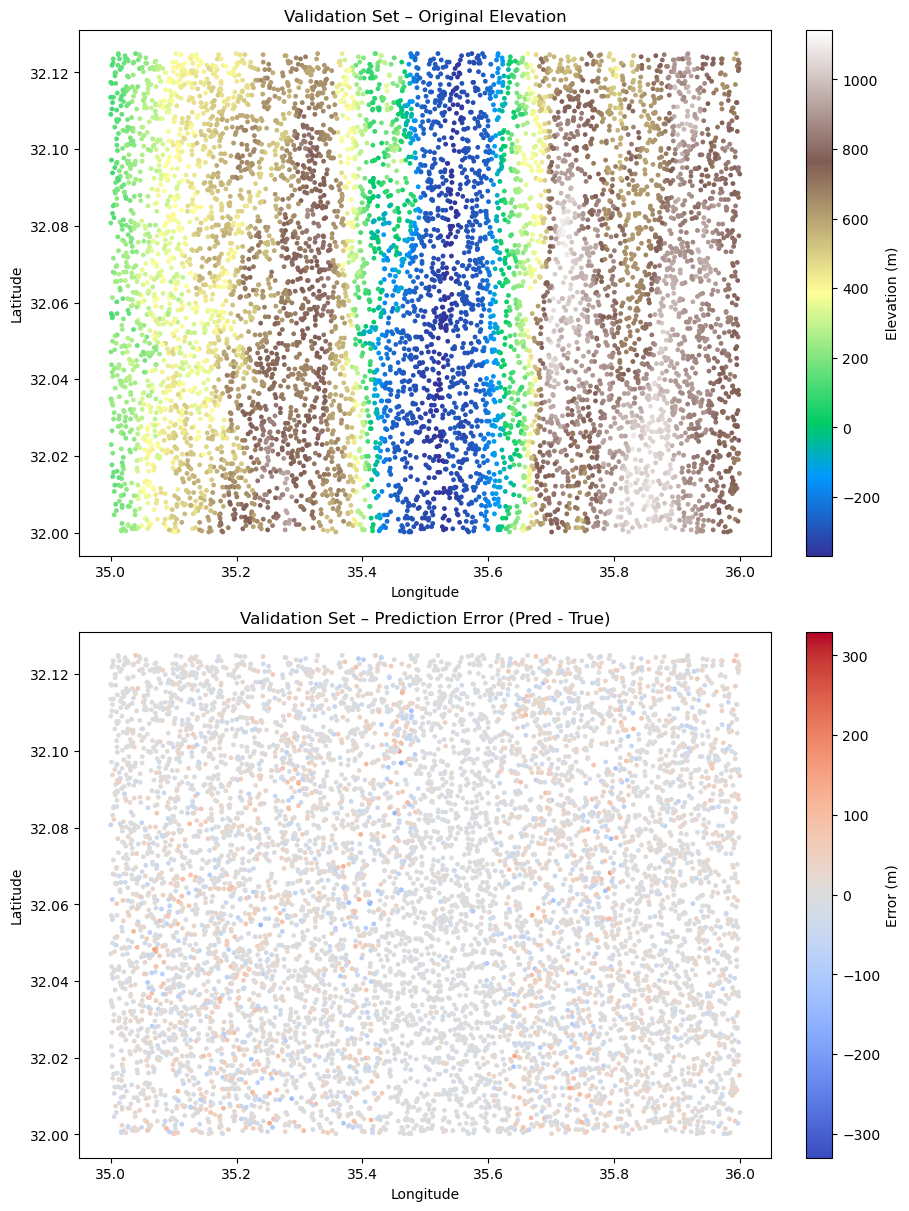

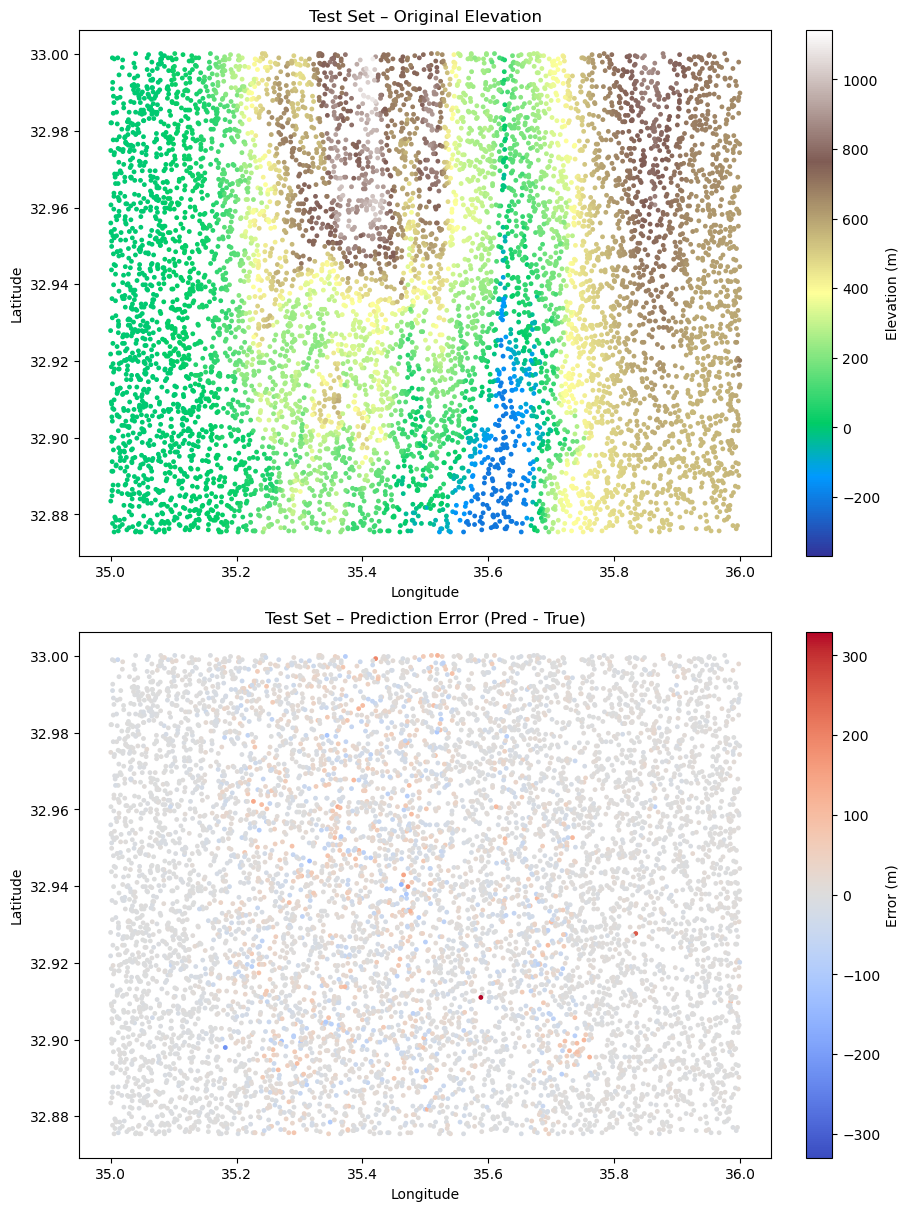

In [82]:
plot_error_map(val_coords,  val_true,  val_err,  "Validation Set",
               elev_norm=elev_norm, err_norm=err_norm, save_name="val_error_map.png")

plot_error_map(test_coords, test_true, test_err, "Test Set",
               elev_norm=elev_norm, err_norm=err_norm, save_name="test_error_map.png")


Display some test's point compared to the GT

In [84]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D plotting)
from scipy.interpolate import griddata
def add_wireframe(ax, coords, y_true, step=80):
    lats, lons, z = coords[:,0], coords[:,1], y_true.flatten()
    lon_lin = np.linspace(lons.min(), lons.max(), step)
    lat_lin = np.linspace(lats.min(), lats.max(), step)
    lon_grid, lat_grid = np.meshgrid(lon_lin, lat_lin)
    z_grid = griddata((lons, lats), z, (lon_grid, lat_grid), method='linear')
    ax.plot_wireframe(lon_grid, lat_grid, z_grid, color='gray', alpha=0.2, rstride=4, cstride=4)
    
def plot_3d_cloud(coords, y_true, y_pred, n_points=3000,seed=42):
    """
    3D scatter plot of test set elevations.
    - Blue: Ground Truth
    - Orange: Predicted
    You can rotate the 3D view to inspect terrain structure.
    """
    random.seed(seed)
    # Subsample for clarity
    if len(coords) > n_points:
        idx = np.random.choice(len(coords), n_points, replace=False)
    else:
        idx = np.arange(len(coords))

    lats = coords[idx, 0]
    lons = coords[idx, 1]
    y_true_s = y_true[idx].flatten()
    y_pred_s = y_pred[idx].flatten()

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Ground truth
    ax.scatter(lons, lats, y_true_s, c='royalblue', label='Ground Truth', s=10, alpha=0.7)

    # Predictions
    ax.scatter(lons, lats, y_pred_s, c='darkorange', label='Prediction', s=10, alpha=0.7)

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_zlabel("Elevation (m)")
    ax.set_title("3D Point Cloud: Ground Truth vs Predicted Elevations (Test Set)")

    ax.legend()
    #add_wireframe(ax, coords[idx], y_true_s)
    plt.tight_layout()
    plt.show()


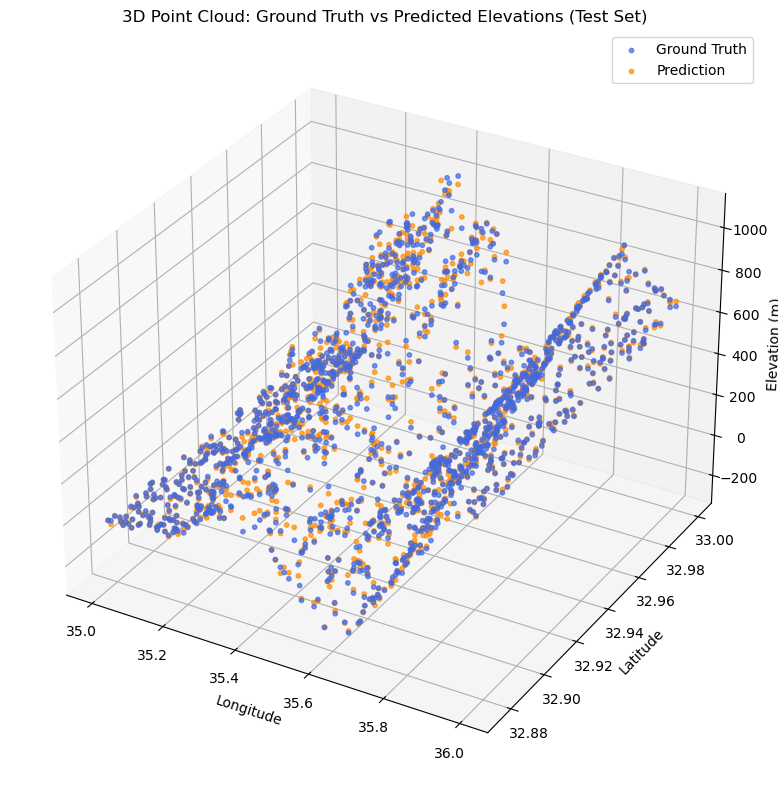

In [85]:
plot_3d_cloud(test_coords, test_true, test_pred, n_points=1500)

In [86]:
from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_surface(coords, y_true, title, step=300):
    """Interpolates both GT and predicted surfaces and shows them as two translucent layers."""
    lats, lons = coords[:,0], coords[:,1]
    z_true = y_true.flatten()#, y_pred.flatten()

    lon_lin = np.linspace(lons.min(), lons.max(), step)
    lat_lin = np.linspace(lats.min(), lats.max(), step)
    lon_grid, lat_grid = np.meshgrid(lon_lin, lat_lin)
    z_true_grid = griddata((lons, lats), z_true, (lon_grid, lat_grid), method='linear')
    #z_pred_grid = griddata((lons, lats), z_pred, (lon_grid, lat_grid), method='linear')

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')

    s1 = ax.plot_surface(lon_grid, lat_grid, z_true_grid, cmap='terrain', alpha=0.8, linewidth=0)
    #fig.colorbar(s1, ax, label="Elevation (m)")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.set_zlabel("Elevation (m)")
    ax.set_title(f"{title}")
    plt.tight_layout()
    plt.show()


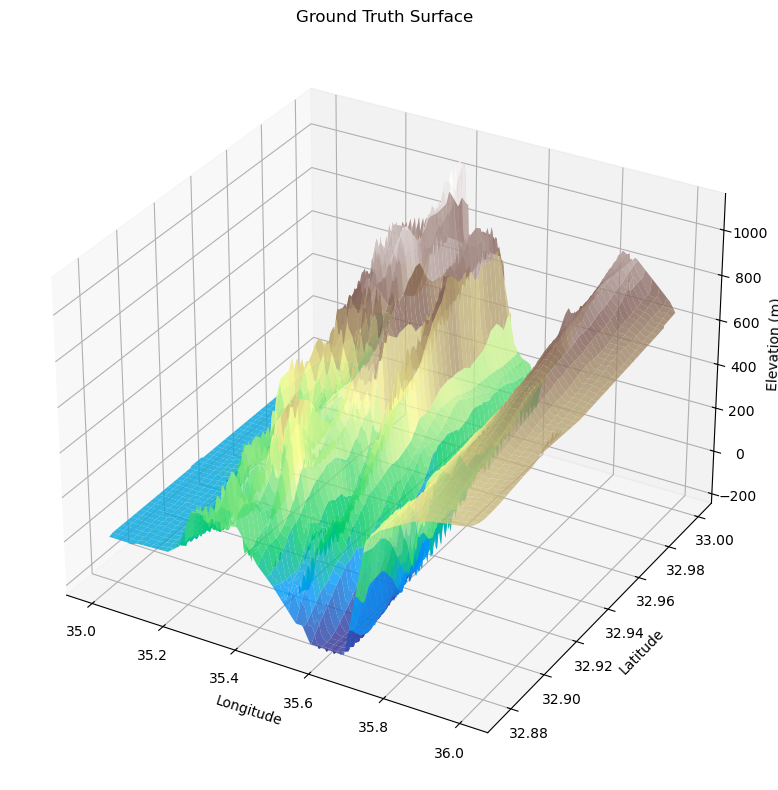

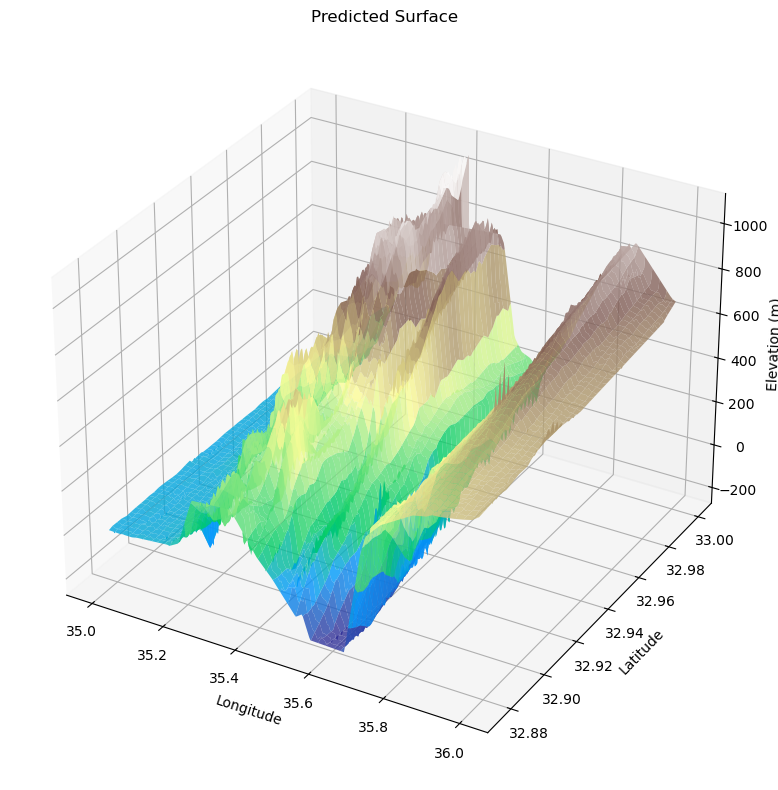

In [87]:
plot_3d_surface(test_coords, test_true, title="Ground Truth Surface")
plot_3d_surface(test_coords, test_pred, title="Predicted Surface")

10
tensor([[[-3.8872e-03, -3.3340e-03, -9.0643e-01],
         [-5.2757e-03,  4.4441e-03, -9.0643e-01],
         [-8.3160e-04, -1.3924e-03, -9.0643e-01],
         [ 1.3885e-03, -2.2240e-03, -9.0643e-01],
         [ 5.5695e-04, -5.0011e-03, -9.0643e-01],
         [ 1.3885e-03,  7.4997e-03, -9.0643e-01],
         [ 0.0000e+00,  6.6643e-03, -9.0643e-01],
         [ 0.0000e+00,  7.4997e-03, -9.0643e-01],
         [ 4.1695e-03,  5.8327e-03, -9.0643e-01],
         [ 3.8910e-03, -6.1111e-03, -9.0643e-01]]], device='cuda:0')

Query #7358: GT=-0.91  |  Pred=-4.45


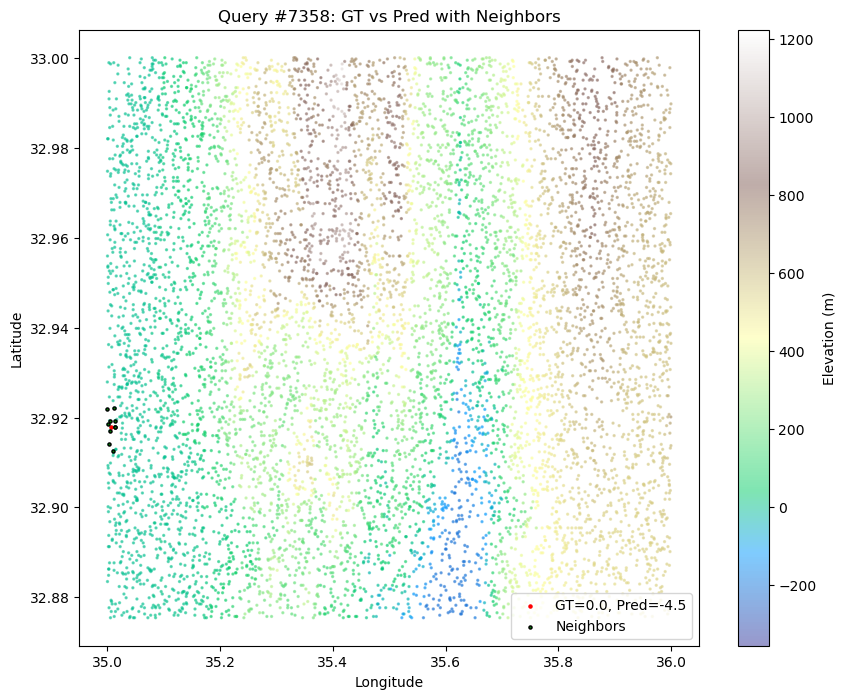

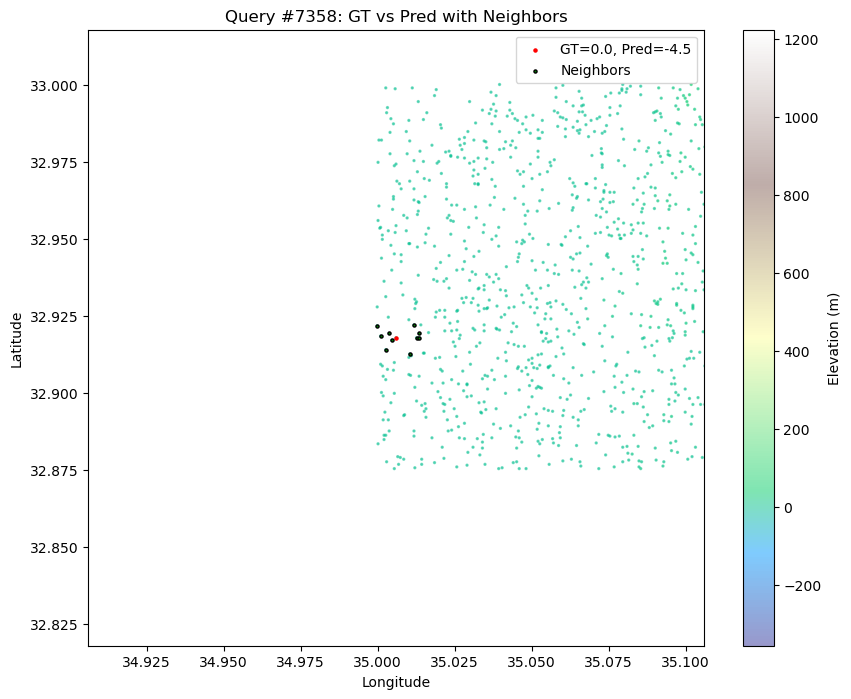

In [25]:
from matplotlib.colors import Normalize, TwoSlopeNorm

# -------------------------------------
# PICK QUERY SAMPLE
# -------------------------------------
i = np.random.randint(len(testset))  # random query from test
q_coord = testset.query_coords[i]    # (lat, lon)
q_gt = testset.query_y[i].item()
obs_coords = testset.obs_coords[i]
obs_y = testset.obs_y[i]
device = 'cuda'
# -------------------------------------
# MODEL PREDICTION
# -------------------------------------
# normalize neighbor coords relative to query
obs_coords_norm = testset.obs_coords_norm[i]
print(len(obs_coords_norm))
obs_y_norm = testset.obs_y_norm[i]

# normalize lat/lon by std
dlat = obs_coords_norm[:, 0] 
dlon = obs_coords_norm[:, 1] 

mem_tokens = torch.stack([dlat, dlon, obs_y_norm.squeeze(-1)], dim=-1).unsqueeze(0).to(device)
print(mem_tokens)
pad_mask = torch.zeros(mem_tokens.size(1), dtype=torch.bool, device=device).unsqueeze(0)

with torch.no_grad():
    y_pred_norm = model(mem_tokens, pad_mask)
y_pred = y_pred_norm * trainset.y_std + trainset.y_mean

print(f"\nQuery #{i}: GT={q_gt:.2f}  |  Pred={y_pred.item():.2f}")

# -------------------------------------
# PLOT MAP + POINTS
# -------------------------------------
elev_min = float(min(trainset.y.min(), testset.y.min()))
elev_max = float(max(trainset.y.max(), testset.y.max()))
elev_norm = Normalize(vmin=elev_min, vmax=elev_max)

plt.figure(figsize=(10, 8))

# === ADD TEST SET POINTS ===
# sc = plt.scatter(trainset.coords[:, 1], trainset.coords[:, 0],
#                  c=trainset.y.squeeze(-1), norm=elev_norm, s=2, cmap="terrain", alpha=0.5)

plt.scatter(testset.coords[:, 1], testset.coords[:, 0],
            c=testset.y.squeeze(-1), norm=elev_norm, s=2, cmap="terrain", alpha=0.5)
plt.colorbar(label="Elevation (m)")
# plt.colorbar(sc, label="Elevation (m)")

# query GT and prediction
plt.scatter(q_coord[1], q_coord[0], c='red', s=5, edgecolors='red', label=f"GT={q_gt* trainset.y_std + trainset.y_mean:.1f}, Pred={y_pred.item():.1f}")
plt.scatter(obs_coords[:,1], obs_coords[:,0], c='green', s=5, edgecolors='k', label="Neighbors")
# plt.scatter(q_coord[1], q_coord[0], c='red', marker='x', s=100, label=f"Pred={y_pred.item():.1f}")

plt.title(f"Query #{i}: GT vs Pred with Neighbors")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()



plt.figure(figsize=(10, 8))
plt.xlim(lon_c - 0.1, lon_c +0.1)
plt.ylim(lat_c - 0.1, lat_c + 0.1)
plt.scatter(testset.coords[:, 1], testset.coords[:, 0],
            c=testset.y.squeeze(-1), norm=elev_norm, s=2, cmap="terrain", alpha=0.5)
plt.colorbar(label="Elevation (m)")
# plt.colorbar(sc, label="Elevation (m)")

# query GT and prediction
plt.scatter(q_coord[1], q_coord[0], c='red', s=5, edgecolors='red', label=f"GT={q_gt* trainset.y_std + trainset.y_mean:.1f}, Pred={y_pred.item():.1f}")
plt.scatter(obs_coords[:,1], obs_coords[:,0], c='green', s=5, edgecolors='k', label="Neighbors")
# plt.scatter(q_coord[1], q_coord[0], c='red', marker='x', s=100, label=f"Pred={y_pred.item():.1f}")

plt.title(f"Query #{i}: GT vs Pred with Neighbors")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()



# ---- zoom to neighbors (+10% padding) ----
lat_c, lon_c = float(q_coord[0]), float(q_coord[1])

plt.xlim(lon_c - 0.1, lon_c +0.1)
plt.ylim(lat_c - 0.1, lat_c + 0.1)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()
#plt.gca().set_aspect('equal', adjustable='box')